# Welcome to the ColliderML tutorial!

This tutorial will guide you through the ColliderML dataset, introduce some of the physics concepts, and give some examples of ML techniques that can be used to study the data.

First, let's actually look at some data! We will need a couple of libraries to read and visualize it. Choose a conda kernel in the top right corner of Jupyter, and make sure you have the following packages installed:

```
module load conda
conda activate [your-conda-env]
pip install h5py pandas numpy matplotlib seaborn
```



Did you do that already? Great! Now let's load those libraries...

In [2]:
%load_ext autoreload
%autoreload 2
# Autoreload is a Jupyter extension that allows you to automatically reload modules when they are changed.

import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import utils # This is some scripts that will help us with the project. You can find them in the /utils folder.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
ttbar_tracks_file = "/global/cfs/cdirs/m4958/data/ColliderML/staging/pileup-10/ttbar/v1/reco/tracks/pileup-10.ttbar.v1.reco.tracks.events0-999.h5"

tracks_df = utils.read_event_tracks(ttbar_tracks_file, 0)

We can quickly break down which data file we are looking at: This is a...
- pileup-10 dataset (that is, one hard scatter collision and ten "soft" or pileup interactions)
- ttbar process (to gluons annihilate into a top quark pair)
- v1 production campaign (the first production campaign of the dataset)
- reco/tracks (tracks are *reconstructed* objects, which means they are inferred from the detector measurements)
- events0-999 (this is a range of events in the file, since we store the dataset in chunks of 1000 events each)

Let's look at the first event in the file:

In [4]:
tracks_df.columns

Index(['track_id', 'num_hits', 'num_outliers', 'num_holes', 'num_shared_hits',
       'chi2', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop',
       'time', 'd0_truth', 'z0_truth', 'phi_truth', 'theta_truth',
       'charge_truth', 'p_truth', 'pT_truth', 'time_truth', 'hit_ids',
       'event_id'],
      dtype='object')

We will get into what all of these columns mean eventually, but for now let's just try to plot them and get some intuition about the type of data.

<Axes: xlabel='d0', ylabel='Count'>

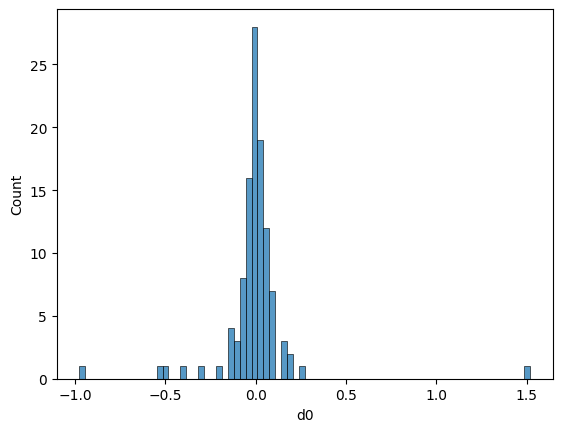

In [5]:
sns.histplot(tracks_df.d0)

So "d0" is *some* property of a track that seems to be centered around 0. Let's try and see what d0 looks like across ALL tracks in the ttbar dataset

In [6]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/staging/pileup-10/ttbar/v1/reco/tracks"
dataset_name = "pileup-10.ttbar.v1.reco"

all_tracks_df = utils.read_events_tracks(base_dir, range(1000), dataset_name)

In [7]:
all_tracks_df

,track_id,num_hits,num_outliers,num_holes,num_shared_hits,chi2,majority_particle_id,d0,z0,phi,...,d0_truth,z0_truth,phi_truth,theta_truth,charge_truth,p_truth,pT_truth,time_truth,hit_ids,event_id
0,109,11,0,0,0,22.2287,906.0,-0.009959,-105.365746,2.993862,...,0.005225,-105.363174,2.993275,0.454270,1,2.446270,1.073440,2425.787842,"[2831, 2911, 3260, 4286, 4298, 5133, 5145, 103...",0
1,108,11,0,0,0,24.3928,2248.0,-0.153666,-11.456075,3.019091,...,-0.006330,-11.761937,3.014571,0.138526,1,8.737208,1.206465,-707.995056,"[2871, 3252, 5637, 5962, 6567, 6903, 7237, 149...",0
2,107,12,0,0,0,21.1790,6436.0,0.008120,-117.511757,2.996826,...,-0.015750,-116.852570,2.997934,2.972549,1,8.368946,1.407987,3995.353760,"[2808, 2877, 1566, 1361, 1262, 1018, 750, 9414...",0
3,106,13,0,0,0,13.8609,6117.0,-0.044598,-116.748528,3.075047,...,-0.015124,-116.794296,3.074344,0.570139,-1,3.714150,2.004709,3995.353516,"[2914, 3290, 4295, 4312, 5153, 5160, 10397, 11...",0
4,105,17,0,0,0,23.8647,3172.0,-0.020431,-41.542458,3.001691,...,-0.007335,-41.525471,3.001153,1.752401,-1,1.213352,1.193398,347.516907,"[2912, 3257, 3287, 4294, 5152, 10420, 10354, 1...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92556,54,15,0,0,0,29.7158,1575.0,-0.018574,-29.663559,1.025349,...,-0.012344,-29.632082,1.024813,1.788164,-1,1.613756,1.575782,-1614.889893,"[2071, 2125, 3250, 4067, 4122, 8781, 8896, 987...",999
92557,55,13,0,0,0,23.5014,3929.0,-0.002116,-4.740641,1.022315,...,0.002668,-4.838809,1.021922,1.999752,1,1.210239,1.100592,-991.529968,"[2079, 2132, 3253, 4048, 4110, 8742, 9797, 985...",999
92558,56,14,0,0,0,31.7405,1446.0,-0.008121,-29.643648,0.950105,...,-0.011912,-29.633087,0.949686,1.597754,1,1.415820,1.415305,-1614.889893,"[2078, 2124, 3251, 4046, 4102, 8715, 9784, 984...",999
92559,57,7,0,0,0,15.5970,4744.0,0.146638,18.354698,0.962133,...,0.012731,18.119768,0.965780,0.101143,1,12.859897,1.298468,-623.372253,"[2037, 2109, 4849, 4852, 5070, 5296, 5535]",999


<Axes: xlabel='d0', ylabel='Count'>

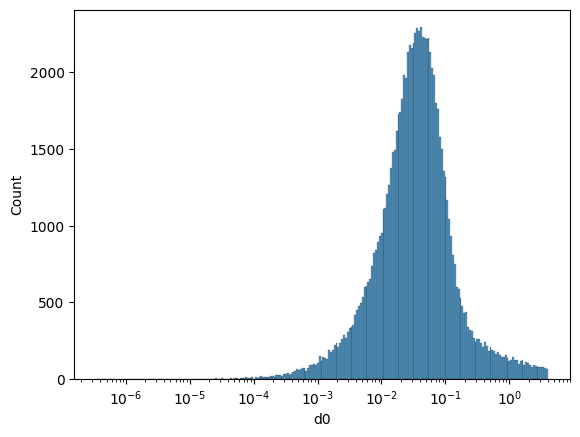

In [7]:
sns.histplot(all_tracks_df.d0.abs(), log_scale=True)

Let's try to take a look at the SUSY dataset now.

In [8]:
susy_base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/staging/pileup-10/susy/v1/reco/tracks"
susy_dataset_name = "pileup-10.susy.v1.reco"

susy_all_tracks_df = utils.read_events_tracks(susy_base_dir, range(1000), susy_dataset_name)
susy_all_tracks_df

,track_id,num_hits,num_outliers,num_holes,num_shared_hits,chi2,majority_particle_id,d0,z0,phi,...,d0_truth,z0_truth,phi_truth,theta_truth,charge_truth,p_truth,pT_truth,time_truth,hit_ids,event_id
0,47,10,0,0,0,10.6191,2155,0.050208,-52.427448,3.124590,...,-0.006200,-52.426674,3.126747,0.581720,-1,4.174341,2.293642,1017.704956,"[1617, 1837, 2421, 2921, 5452, 6151, 6669, 709...",0
1,46,8,0,0,0,23.2761,3929,-0.013263,32.085590,3.026183,...,0.023192,32.142605,3.025004,0.878143,-1,3.082423,2.372093,-1361.604492,"[1620, 1826, 1839, 2410, 2916, 5448, 5408, 6140]",0
2,45,13,0,0,0,22.4272,3010,-0.004005,-52.373413,3.066885,...,-0.029419,-52.406082,3.067561,1.356107,-1,3.237223,3.162905,1017.968628,"[1618, 1836, 2408, 2418, 2915, 5444, 6149, 665...",0
3,44,11,0,0,0,15.1967,2735,-0.002655,-52.502708,2.949178,...,-0.004895,-52.404430,2.950005,2.526398,-1,2.055358,1.186183,1017.705261,"[1570, 1606, 1818, 2405, 2911, 5415, 6146, 665...",0
4,43,14,0,0,0,34.9616,2576,-0.258363,-50.893318,2.815625,...,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN,"[1812, 2390, 2903, 5403, 5392, 6118, 6620, 707...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69231,24,12,0,0,0,18.6487,2835,-0.092957,94.453468,2.072272,...,-0.005044,94.474251,2.069400,1.028918,-1,1.408056,1.206340,629.479858,"[1383, 1604, 2138, 2493, 4762, 5439, 6063, 653...",999
69232,25,9,0,0,0,18.4242,654,1.130982,-31.527521,2.289074,...,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN,"[1618, 2150, 2505, 4772, 5474, 6066, 6536, 837...",999
69233,26,15,0,0,0,17.0410,492,0.011023,-18.486305,2.461920,...,-0.001684,-18.464201,2.461709,0.947335,1,3.226613,2.619566,699.212219,"[1412, 1625, 1650, 2166, 2525, 4806, 4785, 548...",999
69234,27,17,0,0,0,30.9177,245,-0.029437,-18.453415,2.426043,...,-0.002279,-18.464943,2.425820,0.975437,-1,7.884711,6.528125,699.212219,"[1415, 1629, 2167, 2526, 4802, 4780, 5487, 612...",999


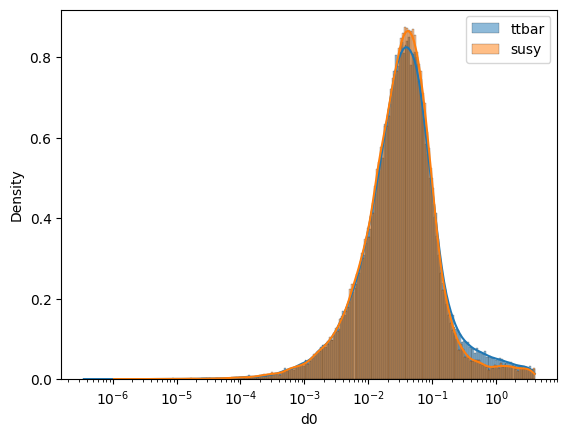

In [36]:
sns.histplot(all_tracks_df.d0.abs(), log_scale=True, label='ttbar', stat='density', kde=True)
sns.histplot(susy_all_tracks_df.d0.abs(), log_scale=True, label='susy', stat='density', kde=True)
plt.legend()


Okay, so in d0, the two datasets look preeeeeetty similar. That makes sense, remember, since of the 11 collisions in each event, 10 are pileup interactions, which are the same in both datasets. So we are really looking for the extra 10% that should be different. 

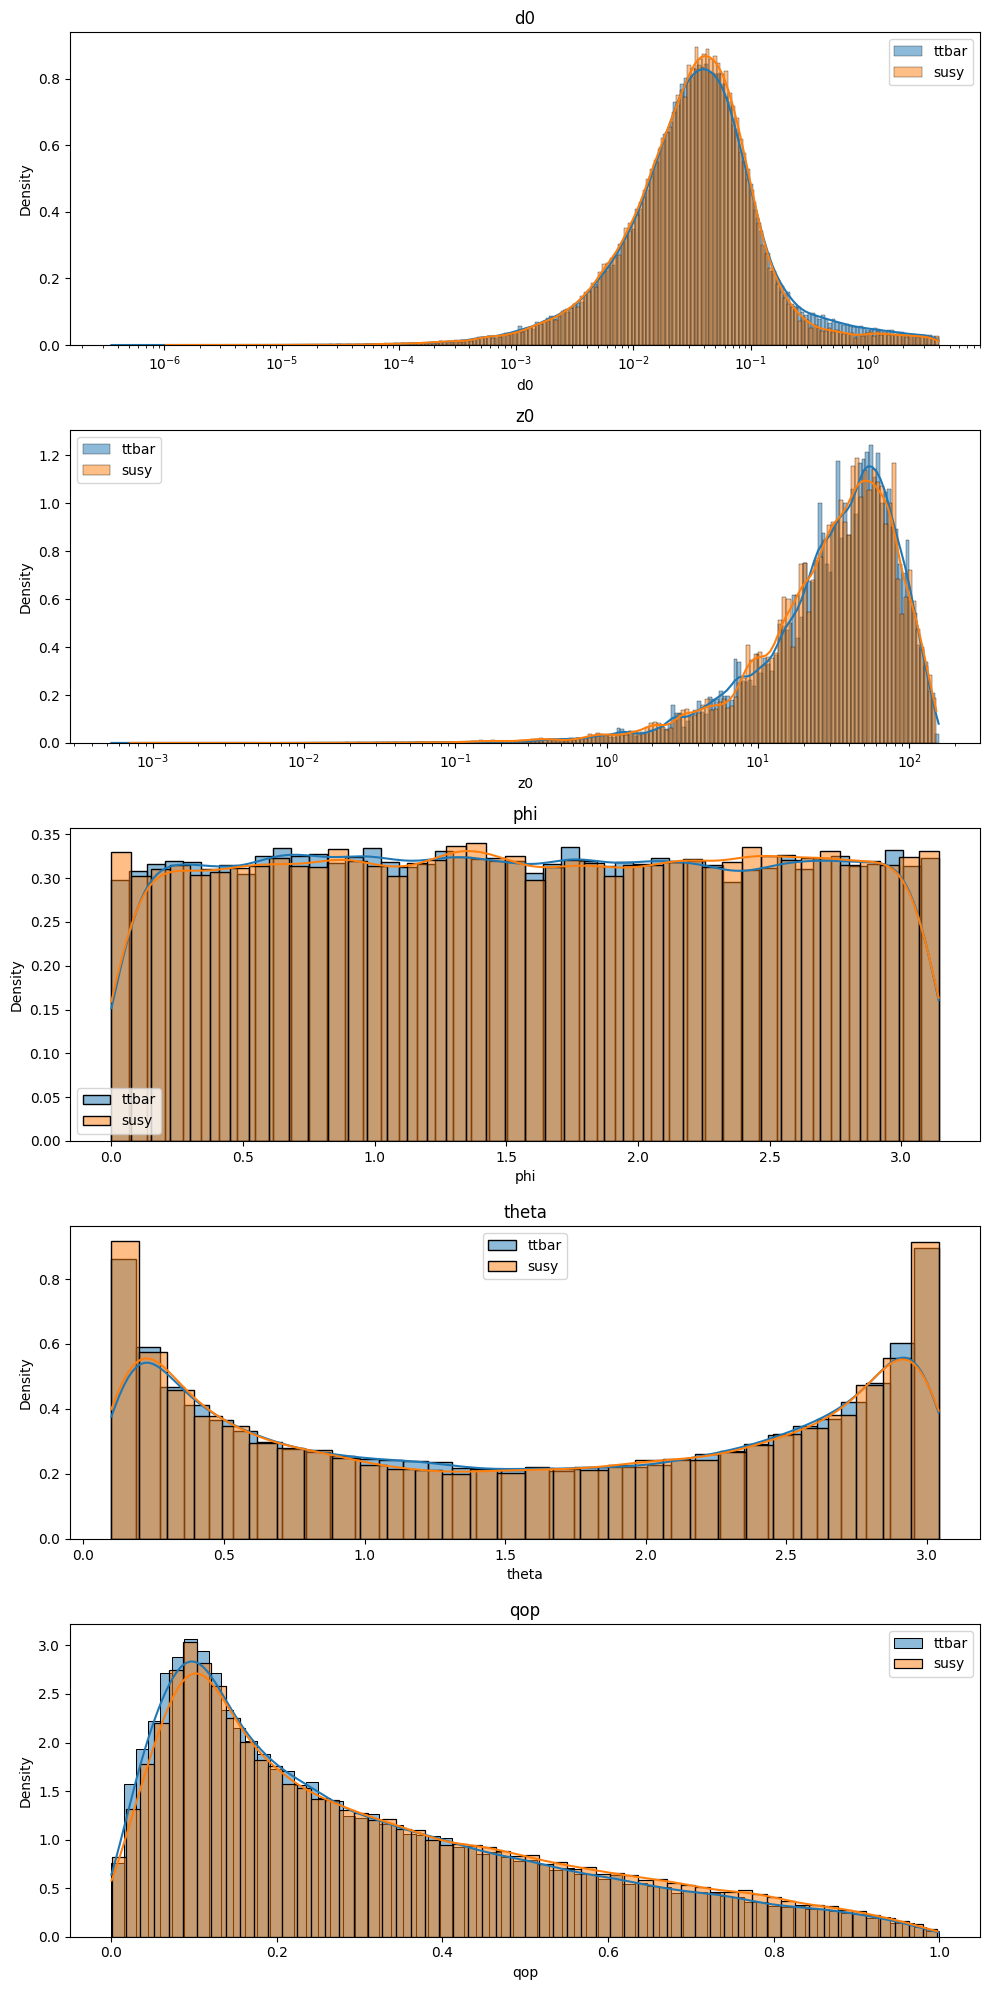

In [9]:
# Plot all the other features of ttbar vs susy
feats_to_plot = ['d0', 'z0', 'phi', 'theta', 'qop']

fig, axes = plt.subplots(len(feats_to_plot), 1, figsize=(10, 4*len(feats_to_plot)))

for i, feat in enumerate(feats_to_plot):
    log_scale = feat in ['d0', 'z0']
    sns.histplot(all_tracks_df[feat].abs(), log_scale=log_scale, label='ttbar', stat='density', kde=True, ax=axes[i])
    sns.histplot(susy_all_tracks_df[feat].abs(), log_scale=log_scale, label='susy', stat='density', kde=True, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].legend()

plt.tight_layout()
plt.show()

Hmmmm, most of these plots look similar between the two. So let's apply some physics knowledge. Remember, SUSY events should have MISSING energy and momentum, since the particles do not interact with regular detector materials. So we need to find out what is the sum of all the track momentum vectors, and see if they sum to zero in the "transverse" (i.e. outwards) direction.

/tmp/ipykernel_2227/2993686417.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ttbar_met = all_tracks_df.groupby('event_id').apply(calculate_met)
/tmp/ipykernel_2227/2993686417.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  susy_met = susy_all_tracks_df.groupby('event_id').apply(calculate_met)


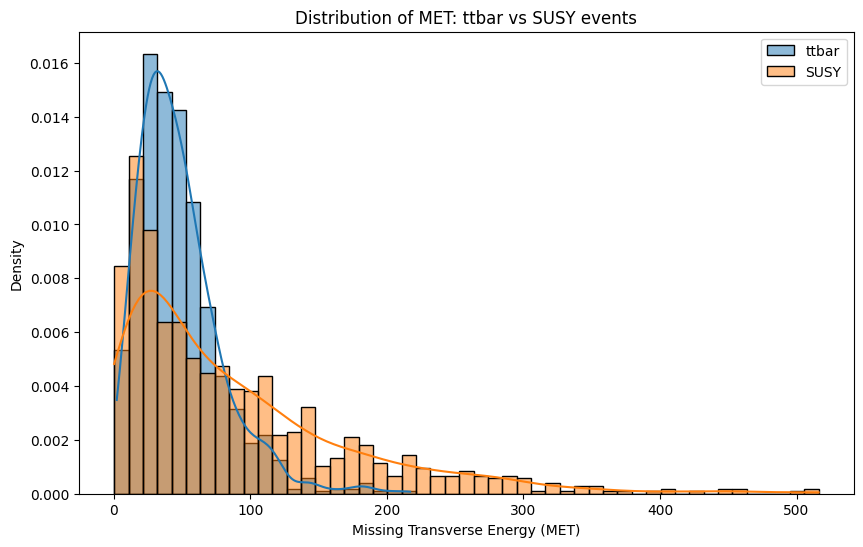


ttbar MET Statistics:
Mean MET: 48.02
Median MET: 41.84
Std MET: 30.97

SUSY MET Statistics:
Mean MET: 88.30
Median MET: 60.81
Std MET: 85.50


In [10]:
# Calculate MET for both ttbar and SUSY events
def calculate_met(group):
    pT = group['pT_truth']
    phi = group['phi_truth']
    
    valid_mask = ~(pT.isna() | phi.isna())
    pT = pT[valid_mask]
    phi = phi[valid_mask]
    
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    
    met = np.sqrt(px.sum()**2 + py.sum()**2)
    return met

# Calculate MET for both datasets
ttbar_met = all_tracks_df.groupby('event_id').apply(calculate_met)
susy_met = susy_all_tracks_df.groupby('event_id').apply(calculate_met)

# Create overlaid histogram
plt.figure(figsize=(10, 6))
# Use the same bins for both histograms by defining a common range
bins = np.linspace(min(ttbar_met.min(), susy_met.min()), 
                   max(ttbar_met.max(), susy_met.max()), 
                   50)

sns.histplot(data=ttbar_met, label='ttbar', alpha=0.5, stat='density', bins=bins, kde=True)
sns.histplot(data=susy_met, label='SUSY', alpha=0.5, stat='density', bins=bins, kde=True)
plt.xlabel('Missing Transverse Energy (MET)')
plt.ylabel('Density')
plt.title('Distribution of MET: ttbar vs SUSY events')
plt.legend()
plt.show()

# Print statistics for both
print("\nttbar MET Statistics:")
print(f"Mean MET: {ttbar_met.mean():.2f}")
print(f"Median MET: {ttbar_met.median():.2f}")
print(f"Std MET: {ttbar_met.std():.2f}")

print("\nSUSY MET Statistics:")
print(f"Mean MET: {susy_met.mean():.2f}")
print(f"Median MET: {susy_met.median():.2f}")
print(f"Std MET: {susy_met.std():.2f}")

Aha! The SUSY events have a *much* longer tail of missing transverse energy. That shows that we can start to detect them even with some simple cuts. Let's try to "cut" events above MET=200 and see good this detection technique is.